## Genera usuarios sintéticos

# Importaciones

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker

sns.set_theme(style='whitegrid')
fake = Faker('es_MX')       # nombres en español
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
Faker.seed(SEED)


ITEMS_PATH = Path('/data/processed/items.csv')
if not ITEMS_PATH.exists():
	ITEMS_PATH = Path('../../data/processed/items.csv')
 
OUTPUT_PATH = Path('/data/processed/items.csv')
if not OUTPUT_PATH.exists():
	OUTPUT_PATH = Path('../../data/processed/users.csv')

N_USERS = 15000  

# Se obtienen los géneros del dataset original

In [6]:
items = pd.read_csv(ITEMS_PATH)

# Géneros disponibles en el dataset
generos_disponibles = sorted(items['genero'].unique().tolist())
print(f'Géneros disponibles ({len(generos_disponibles)}):')
print(generos_disponibles)

Géneros disponibles (114):
['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-rock', 'punk', 'punk-rock', 'r-n-b', 're

# Se generan Usuarios Sintéticos

In [7]:
# Distribución de edades por segmento (más realista que uniforme)
# Los servicios de streaming tienen más usuarios jóvenes
def generar_edad():
    segmentos = [
        (13, 17, 0.10),   # adolescentes
        (18, 24, 0.30),   # universitarios
        (25, 34, 0.30),   # jóvenes adultos
        (35, 50, 0.20),   # adultos
        (51, 70, 0.10),   # mayores
    ]
    pesos = [s[2] for s in segmentos]
    seg = random.choices(segmentos, weights=pesos, k=1)[0]
    return random.randint(seg[0], seg[1])

# Cada usuario tiene 1 o 2 géneros favoritos
def generar_generos_favoritos():
    n = random.choices([1, 2], weights=[0.6, 0.4])[0]
    return '|'.join(random.sample(generos_disponibles, n))

# Generar los usuarios
usuarios = []
for i in range(1, N_USERS + 1):
    usuarios.append({
        'USER_ID'          : f'user_{i:04d}',
        'nombre'           : fake.first_name(),
        'edad'             : generar_edad(),
        'genero_favorito'  : generar_generos_favoritos()
    })

users = pd.DataFrame(usuarios)
print(f'Usuarios generados: {len(users)}')
users.head(10)

Usuarios generados: 15000


,USER_ID,nombre,edad,genero_favorito
0,user_0001,Silvia,25,electro|dub
1,user_0002,Francisco Javier,18,malay|british
2,user_0003,Alvaro,25,drum-and-bass
3,user_0004,Roberto,22,disco
4,user_0005,Óscar,48,new-age
5,user_0006,Mateo,24,soul
6,user_0007,Homero,21,country
7,user_0008,Felix,24,british
8,user_0009,Zoé,20,pagode|emo
9,user_0010,María del Carmen,49,hardcore


# Se verifica la distribución

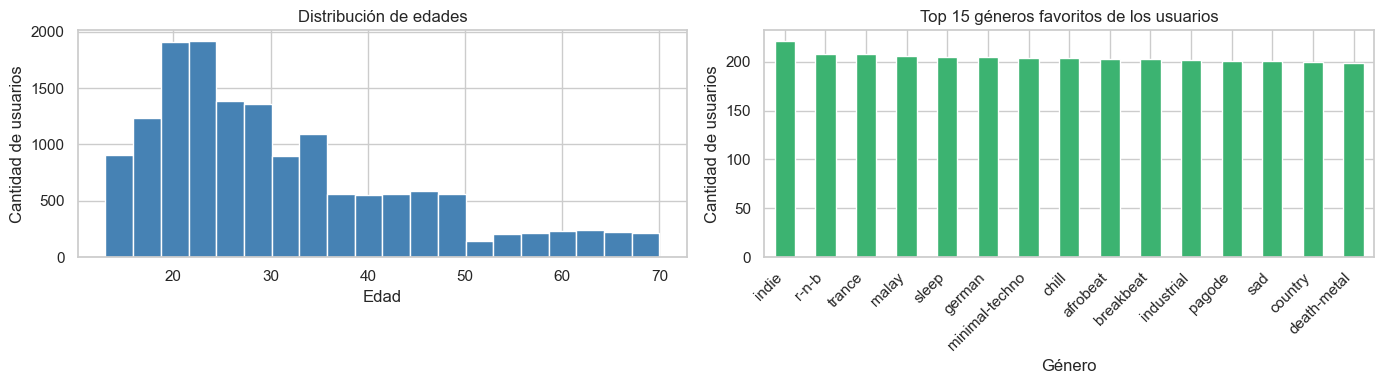

In [8]:
# Distribución de edades
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(users['edad'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de edades')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Cantidad de usuarios')

# Géneros favoritos más comunes (expandir el campo separado por |)
generos_expandidos = users['genero_favorito'].str.split('|').explode()
top_generos = generos_expandidos.value_counts().head(15)
top_generos.plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Top 15 géneros favoritos de los usuarios')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Cantidad de usuarios')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [9]:
# Resumen estadístico
print('Estadísticas de edad:')
print(users['edad'].describe())
print(f'\nUsuarios con 1 género favorito:  {users["genero_favorito"].str.count("\\|").eq(0).sum()}')
print(f'Usuarios con 2 géneros favoritos: {users["genero_favorito"].str.count("\\|").eq(1).sum()}')

Estadísticas de edad:
count    15000.000000
mean        31.209733
std         13.421292
min         13.000000
25%         21.000000
50%         28.000000
75%         38.000000
max         70.000000
Name: edad, dtype: float64

Usuarios con 1 género favorito:  8905
Usuarios con 2 géneros favoritos: 6095


# Exportar CVS

In [10]:
import os
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

users.to_csv(OUTPUT_PATH, index=False)
print(f'users.csv guardado en: {OUTPUT_PATH}')
print(f'{len(users):,} usuarios exportados')
print(f'Columnas: {list(users.columns)}')

users.csv guardado en: ..\..\data\processed\users.csv
15,000 usuarios exportados
Columnas: ['USER_ID', 'nombre', 'edad', 'genero_favorito']
